In [ ]:
pip install "modin[all]" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.5/133.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 4.5 MB/s eta 0:00:00


# --

## install/import/read

In [1]:
import modin.pandas as pd
import pandas
import time
from IPython.display import Markdown, display

def printmd(string):
    display(Markdown(string))

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

path = "/content/gdrive/MyDrive/modin/taxi.csv"

Mounted at /content/gdrive


In [ ]:
pandas_df = pandas.read_csv(path, parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"], quoting=3)
modin_df  = pd.read_csv(path, parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"], quoting=3)

2025-05-19 14:18:33,875	INFO worker.py:1888 -- Started a local Ray instance.


# read time

In [ ]:
%timeit pandas.read_csv(path, parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"], quoting=3)

6.69 s ± 886 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
import multiprocessing
cores = multiprocessing.cpu_count() # Count the number of cores in a computer
cores

2

In [ ]:
%timeit pd.read_csv(path, parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"], quoting=3)

15.5 s ± 552 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# algunos operadores

## reduce (count)

In pandas, a reduce would be something along the lines of a `sum` or `count`. It computes some summary statistics about the rows or columns. We will be using `count`.

In [ ]:
%timeit pandas_count = pandas_df.count()

237 ms ± 48.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%timeit modin_count = modin_df.count()

22.9 ms ± 3.47 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


## map

In pandas, map operations are operations that do a single pass over the data and do not change its shape. Operations like `isnull` and `applymap` are included in this. We will be using `isnull`.

In [ ]:
%timeit pandas_df.isnull()

173 ms ± 38.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%timeit modin_df.isnull()

4.59 ms ± 1.14 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


## apply (sobre una columna)

Sometimes we want to compute some summary statistics on a single column from our dataset.

In [ ]:
%timeit pandas_df["trip_distance"].apply(round)

1.31 s ± 178 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%timeit modin_df["trip_distance"].apply(round)

2.64 s ± 644 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## add

It is common to need to add a new column to an existing dataframe, here we show that this is significantly faster in Modin due to metadata management and an efficient zero copy implementation.

In [ ]:
rounded_trip_distance_pandas = pandas_df["trip_distance"].apply(round)
rounded_trip_distance_modin = modin_df["trip_distance"].apply(round)

In [ ]:
%timeit pandas_df["rounded_trip_distance"] = rounded_trip_distance_pandas

CPU times: user 3.68 ms, sys: 66 µs, total: 3.74 ms
Wall time: 5.82 ms


In [ ]:
%timeit modin_df["rounded_trip_distance"] = rounded_trip_distance_modin

5.05 ms ± 1.06 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


# concat multiple

In [ ]:
N_copies= 60
start = time.time()

big_modin_df = pd.concat([modin_df for _ in range(N_copies)])

end = time.time()
modin_duration = end - start
print("Time to concat with Modin: {} seconds".format(round(modin_duration, 3)))

Time to concat with Modin: 0.275 seconds


In [ ]:
start = time.time()

big_pandas_df = pandas.concat([pandas_df for _ in range(N_copies)])

end = time.time()
pandas_duration = end - start
print("Time to concat with pandas: {} seconds".format(round(pandas_duration, 3)))

# configurations

metodos:
- get()
- put()

In [ ]:
from multiprocessing import cpu_count
import modin.config as cfg

print(cfg.Engine.get())
print(cfg.NPartitions.get())

Ray
2


How many partitions to use for a Modin DataFrame (along each axis).

In [ ]:
cfg.NPartitions.put(16)
print(cfg.NPartitions.get())
cfg.NPartitions.put(cpu_count())

2


In [ ]:
cpu_count()

2

# range partitioning

In [ ]:
import numpy as np
frame_data = np.random.randint(0, 100, size=(2**18, 2**8))
df = pd.DataFrame(frame_data).add_prefix("col")
df = df.applymap(lambda x: ~x)

first_column_name = df.columns[0]
first_column_name

'col0'

In [ ]:
df_range = df.copy()
df_notrange = df.copy()

%time df_notrange.groupby(first_column_name).mean(); # use MapReduce implementation for groupby.mean()

with cfg.context(RangePartitioning=True):
  %time df_range.groupby(first_column_name).mean() # use range-partitioning for groupby.mean()

CPU times: user 94.5 ms, sys: 15.4 ms, total: 110 ms
Wall time: 2.01 s
CPU times: user 370 ms, sys: 18.5 ms, total: 388 ms
Wall time: 2.39 s


# dynamic partitioning

In [ ]:
%timeit -r 10 -n 200 df.abs()

with cfg.context(DynamicPartitioning=True):
    %timeit -r 10 -n 200 df.abs()

7.69 ms ± 2.25 ms per loop (mean ± std. dev. of 10 runs, 200 loops each)
7.18 ms ± 1.39 ms per loop (mean ± std. dev. of 10 runs, 200 loops each)


# tune partitioning

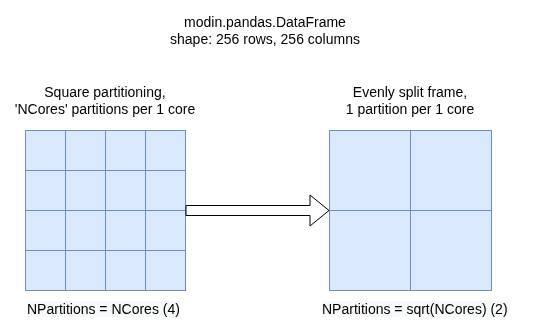

If your workflow mainly operates with wide dataframes and non-full-axis functions, it makes sense to reduce the NPartitions value so a single worker would process a single partition.

In [ ]:
from multiprocessing import cpu_count
from modin.distributed.dataframe.pandas import unwrap_partitions
import modin.config as cfg
import modin.pandas as pd
import numpy as np
import timeit

data = np.random.randint(0, 100, size=(5000, 5000))

cfg.NPartitions.put(cpu_count())

df = pd.DataFrame(data)
print()
print(f"NPartitions: {cfg.NPartitions.get()}")

partitions_shape = np.array(unwrap_partitions(df)).shape
print(
    f"The frame has {partitions_shape[0]}x{partitions_shape[1]}={np.prod(partitions_shape)} partitions "
    f"when the CPU has only {cpu_count()} cores."
)
print(f"10 times of .abs(): {timeit.timeit(lambda: df.abs(), number=10)}s.")
# Possible output:
#   NPartitions: 112
#   The frame has 112x112=12544 partitions when the CPU has only 112 cores.
#   10 times of .abs(): 23.64s.

# Taking a square root of the the current `cpu_count` to make more even partitioning
cfg.NPartitions.put(int(cpu_count() ** 0.5))

# Each worker processes a single partition
df = pd.DataFrame(data)
print()
print(f"NPartitions: {cfg.NPartitions.get()}")
# Getting raw partitions to count them
partitions_shape = np.array(unwrap_partitions(df)).shape
print(
    f"The frame has {partitions_shape[0]}x{partitions_shape[1]}={np.prod(partitions_shape)} "
    f"when the CPU has {cpu_count()} cores."
)
print(f"10 times of .abs(): {timeit.timeit(lambda: df.abs(), number=10)}s.")


NPartitions: 2
The frame has 2x2=4 partitions when the CPU has only 2 cores.
10 times of .abs(): 0.0722995969999829s.



NPartitions: 1
The frame has 1x1=1 when the CPU has 2 cores.
10 times of .abs(): 0.06334167099998922s.


# not iterate

In [ ]:
from timeit import default_timer as timer

cfg.NPartitions.put(cpu_count())

data = np.random.randint(1, 100, (2 ** 10, 2 ** 2))

md_df = pd.DataFrame(data)

result = []
t1 = timer()
for idx, row in md_df.iterrows():
    result.append((row[1] + row[2]) / row[3])
print(f"Filling a list by iterating a Modin frame: {timer() - t1:.2f}s.")

t1 = timer()
result = md_df.apply(lambda row: (row[1] + row[2]) / row[3], axis=1).to_numpy().tolist()
print(f"Filling a list by using '.apply()' and converting the result to a list: {timer() - t1:.2f}s.")

Filling a list by iterating a Modin frame: 44.58s.
Filling a list by using '.apply()' and converting the result to a list: 0.06s.


# progessbar

In [4]:
import numpy as np

from modin.config import ProgressBar
ProgressBar.enable()

frame_data = np.random.randint(0, 100, size=(2**18, 2**8))
df = pd.DataFrame(frame_data).add_prefix("col")

Distributing Dataframe:   0%           Elapsed time: 00:00, estimated remaining time: ?

In [5]:
df = df.applymap(lambda x: ~x)
ProgressBar.disable()

Estimated completion of line 1:   0%           Elapsed time: 00:00, estimated remaining time: ?